# Building an inversion from scratch and checking the effects of regularization

In this notebook, we'll build a **gravity inversion** setup to estimate the relief of a sedimentary basin.

We'll implement **regularization** to stabilize the solution.

We'll also see how we can break the inversion by adding random noise, abusing regularization, and breaking the underlying assumptions.

## What to watch for
- **Observed vs predicted** gravity (fit quality)  
- **True vs estimated** basin boundary (geometry)    
- **Noise experiments:** how stable is the estimate across realizations?  
- **Regularization ($\beta$) effects:** how adding regularization constraints affects the solution.

Adapted from [this notebook](https://github.com/compgeolab/2020-aachen-inverse-problems/blob/main/gravity-inversion-solution.ipynb) from a short course on geophysical inversion at RWTH Aachen University, Germany.

| Author                             | Contact                             |
| :---------------------------------- | :---------------------------------- |
| [Polyanna Rowe](https://github.com/polyye) | [polyannar@mirageoscience.com](mailto:polyannar@mirageoscience.com) |

## Imports

We'll use the basic scientific Python libraries for this tutorial plus some custom functions, which are based on the code from the [Harmonica](https://github.com/fatiando/harmonica) library.

In [1]:
# Libs
import numpy as np
import matplotlib.pyplot as plt

# Make the resolution of the matplotlib figures better for larger screens
plt.rc("figure", dpi=120)

# Custom Functions 

Here, we define several functions to build the gravity inversion setup including synthetic model generation, plotting the model, and forward modeling of the model response, i.e. predicting the gravity effect of the model.


In [2]:
# Function to plot prisms outline (basin depth)
def plot_prisms(
    depths,
    basin_boundaries,
    ax=None,
    edgecolor="black",
    linewidth=1.5,
    linestyle="-",
    label=None,
    figsize=(9, 3),
):
    """
    Plot the basin outline (no fill).
    """
    # Basin boundaries for each prism column
    boundaries = np.linspace(*basin_boundaries, depths.size + 1)

    # Build outline polyline
    x = [boundaries[0]]
    y = [0.0]
    for i in range(depths.size):
        x.extend([boundaries[i], boundaries[i + 1]])
        y.extend([depths[i], depths[i]])
    x.append(boundaries[-1])
    y.append(0.0)

    # Convert to km
    x = np.array(x) / 1000.0
    y = np.array(y) / 1000.0

    # Setup axes
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_xlabel("x [km]", fontsize=12)
        ax.set_ylabel("depth [km]", fontsize=12)

    # Plot only the outline
    ax.plot(x, y, color=edgecolor, linewidth=linewidth, linestyle=linestyle, label=label)

    # Formatting
    ax.invert_yaxis()
    ax.set_ylim(max(y) * 1.1, 0.0)
    ax.grid(alpha=0.3, linestyle="--")
    if label is not None:
        ax.legend()
    return ax

# Define Gaussian function for computing a synthetic basin model
def gaussian(x: np.ndarray, shift: float, std: float, amplitude: float) -> np.ndarray:
    """
    Simple Gaussian bump used to build a synthetic basin.

    This is not a strict Gaussian PDF; it is a simple bump function.
    """
    return amplitude * np.exp(-((x - shift) / std) ** 2)

# Generate synthetic model using Gaussian function
def synthetic_model(
    size: int = 100,
    basin_boundaries: tuple[float, float] = (0.0, 100e3),
) -> tuple[np.ndarray, tuple[float, float]]:
    """
    Generate a synthetic basin with two Gaussian lobes, top fixed at z=0.
    """
    boundaries = np.linspace(*basin_boundaries, size + 1)
    x = boundaries[:-1] + 0.5 * (boundaries[1] - boundaries[0])
    depths = (
        gaussian(x, shift=45e3, std=20e3, amplitude=5e3)
        + gaussian(x, shift=80e3, std=10e3, amplitude=1e3)
    )

    # Ensure the basin meets the surface at the edges to avoid steps
    depths = depths - depths.min()
    depths[0] = 0.0
    depths[-1] = 0.0

    return depths, basin_boundaries

# Calculate the boundaries of the prisms
def prism_boundaries(depths: np.ndarray, basin_boundaries: tuple[float, float]) -> np.ndarray:
    """
    Compute x-coordinates of prism boundaries (depths.size + 1).
    """
    return np.linspace(*basin_boundaries, depths.size + 1)

# Kernel function for calculating the vertical component of gravity on a prism
def kernel(easting, northing, upward):
    """
    Nagy et al. (2000) kernel for gz contribution from a rectangular prism corner.
    """
    e = np.asarray(easting)
    n = np.asarray(northing)
    u = np.asarray(upward)
    r = np.sqrt(e*e + n*n + u*u)
    eps = 1e-12  # avoid log(0)
    return e*np.log(n + r + eps) + n*np.log(e + r + eps) + u*np.arctan2(e*n, -u*r)


# Calculate the gravity of a single prism
def prism_gravity(
    x, east, west, top, bottom, density, output=None, y_half_extent=200e3, z_obs=10.0
):
    """
    Add gz from one prism (infinite-ish in y via large half-extent) to `output`.
    """
    if output is None:
        output = np.zeros_like(x, dtype=float)

    # Sort faces (left/right)
    west, east = sorted((west, east))

    # Prism limits in (x, y, z). z positive upward in kernel; we store negative depths.
    prism = [west, east, -y_half_extent, y_half_extent, -bottom, -top]

    # Constants & scaling
    G_SI = 6.67430e-11  # m^3 kg^-1 s^-2
    SI2mGal = 1e5       # 1 m/s^2 = 1e5 mGal
    scale = G_SI * density * SI2mGal

    # 8 corner contributions
    for i in (0, 1):
        for j in (0, 1):
            for k in (0, 1):
                e = prism[1 - i] - x
                n = prism[3 - j]
                u = prism[5 - k] - z_obs
                output += ((-1) ** (i + j + k)) * scale * kernel(e, n, u)
    return output

# Forward model for predicting gravity response
def forward_model(
    depths: np.ndarray,
    basin_boundaries: tuple[float, float],
    density: float,
    x: np.ndarray,
    y_half_extent: float = 200e3,
    z_obs: float = 10.0,
) -> np.ndarray:
    """
    Predict gz at positions x (m) for a basin made of vertical prisms with top at z=0.
    """
    boundaries = prism_boundaries(depths, basin_boundaries)
    gz = np.zeros_like(x, dtype=float)
    for m in range(depths.size):
        prism_gravity(
            x,
            boundaries[m], boundaries[m + 1],
            top=0.0, bottom=float(depths[m]),
            density=density,
            output=gz,
            y_half_extent=y_half_extent,
            z_obs=z_obs,
        )
    return gz

## Modelling Assumptions

1. The basin is **y-invariant** (effectively infinite in *y*), so the problem is **2D** in *(x, z)*.  
2. The measured **gravity disturbance** is caused **only** by the sedimentary basin.  
3. The **top of the basin** is a flat datum at $z = 0$ (no surface topography).  
4. Data are collected along a profile at a **constant height** $z_{\text{obs}} = 1\,\text{m}$.

### Implications for the forward model

- We represent the basin as a stack of **vertical prisms** with **tops at $z=0$** and **bottoms at $z=h(x)$** (the basin depth).  
- The basin has a **uniform density contrast** $\Delta\rho$ relative to the basement.  
- The forward response is the **sum of gravity from these prisms only**; material below $h(x)$ is taken as **zero contrast** (no contribution).  
- No regional trend or topography is included; calculations are per unit length in the out-of-plane $y$ direction.


## Generating the basin model

First, we'll create a synthetic basin model using one of the functions defined earlier.

In [3]:
# Generate a basin using a Gaussian shape
depths, basin_boundaries = synthetic_model()

# Show results
print("Basin x-range (m):", basin_boundaries)
print("Number of prisms :", depths.size)
print("Depths (m):")
print(depths)

Basin x-range (m): (0.0, 100000.0)
Number of prisms : 100
Depths (m):
[   0.           18.81092435   29.38998081   42.16839388   57.51774684
   75.85246428   97.63037844  123.35222519  153.55985009  188.83290654
  229.78383989  277.05097454  331.28955675  393.1606554   463.31788573
  542.39199706  630.97345373  729.59323554  838.70218841  958.64936255
 1089.65988011 1231.81297121 1385.02090173 1549.00958058 1723.30167502
 1907.20307243 2099.79350393 2299.92208393 2506.20842163 2717.04982321
 2930.63493217 3144.96395261 3357.87537423 3567.07887609 3770.19383914
 3964.79265602 4148.44780248 4318.78143888 4473.51615424 4610.52535757
 4727.88177002 4823.90248153 4897.18910944 4946.66173395 4971.58548322
 4971.58889307 4946.67346668 4897.21419639 4823.95117457 4727.97279851
 4610.69145219 4473.81290687 4319.30099926 4149.33939015 3966.2923388
 3772.66640115 3571.07472151 3364.2050895  3154.79214739 2945.59306685
 2739.36473798 2538.83917762 2346.69270631 2165.50377716 1997.6945141
 1845.452

## Plot the model

<Axes: xlabel='x [km]', ylabel='depth [km]'>

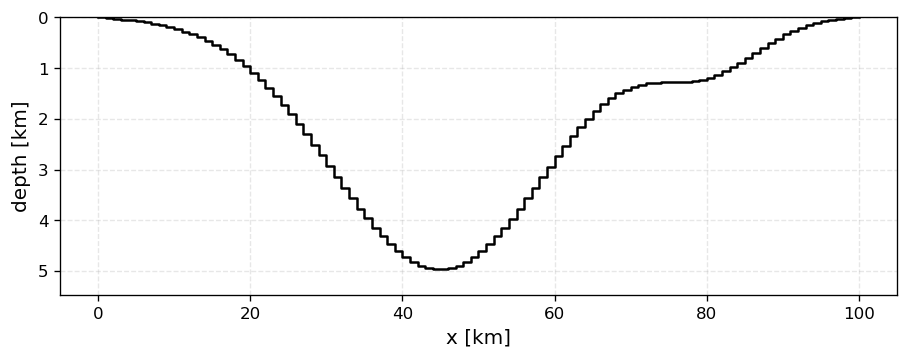

In [4]:
plot_prisms(depths, basin_boundaries)

## Compute the gravity response of this model

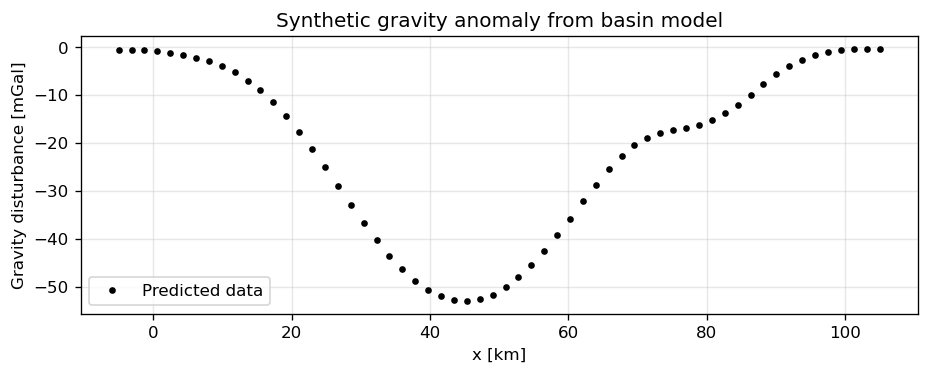

In [10]:
# Forward model: compute gravity response

# Observation points along the profile (from -5 km to 105 km)
x = np.linspace(-5e3, 105e3, 60)  

# Density contrast between basin fill and basement (kg/m³)
density = -300  

# Predicted gravity anomaly
data = forward_model(depths, basin_boundaries, density, x)

# Plot results
plt.figure(figsize=(9, 3))
plt.plot(x / 1000, data, ".k", label="Predicted data")
plt.xlabel("x [km]")
plt.ylabel("Gravity disturbance [mGal]")
plt.title("Synthetic gravity anomaly from basin model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Jacobian (sensitivity matrix)

The **Jacobian** is basically a table (matrix) showing how (by how much) each data point changes when each model parameter changes. 
    
- **Rows** = data points (gravity at each x)  
- **Columns** = parameters (basin prism depths)  
- **Entry**: $J[i,j] \approx \Delta d_i / \Delta m_j$  (units ≈ mGal per m)


> In short: the Jacobian is just a table of “cause → effect” numbers.  
> We gently change each parameter and record how the data respond.


In [11]:
def make_jacobian(depths, basin_boundaries, density, x, delta=10):
    """
    Build the Jacobian (sensitivity) matrix by finite differences.
    
    Each column j gives the change in predicted data at all observation points
    when the depth of prism j is perturbed by a small amount (delta).

    Parameters
    ----------
    depths : array
        Current depth values for each prism (the model parameters).
    basin_boundaries : tuple
        Start and end x-coordinates of the basin.
    density : float
        Density contrast (kg/m^3).
    x : array
        Observation locations along profile.
    delta : float, optional
        Small perturbation size (in meters). Default is 10 m.

    Returns
    -------
    jacobian : 2D array of shape (n_data, n_parameters)
        Sensitivity matrix. Entry (i, j) is the change in datum i
        when parameter j is perturbed by delta.
    """
    n_data = x.size
    n_params = depths.size
    jacobian = np.empty((n_data, n_params))

    # Loop over each parameter (prism depth)
    for j in range(n_params):
        step = np.zeros_like(depths)
        step[j] = delta

        # Forward responses for perturbed vs original depth
        f_plus = forward_model(depths + step, basin_boundaries, density, x)
        f_base = forward_model(depths, basin_boundaries, density, x)

        # Approximate derivative by finite difference
        jacobian[:, j] = (f_plus - f_base) / delta

    return jacobian

## Build and visualize the Jacobian


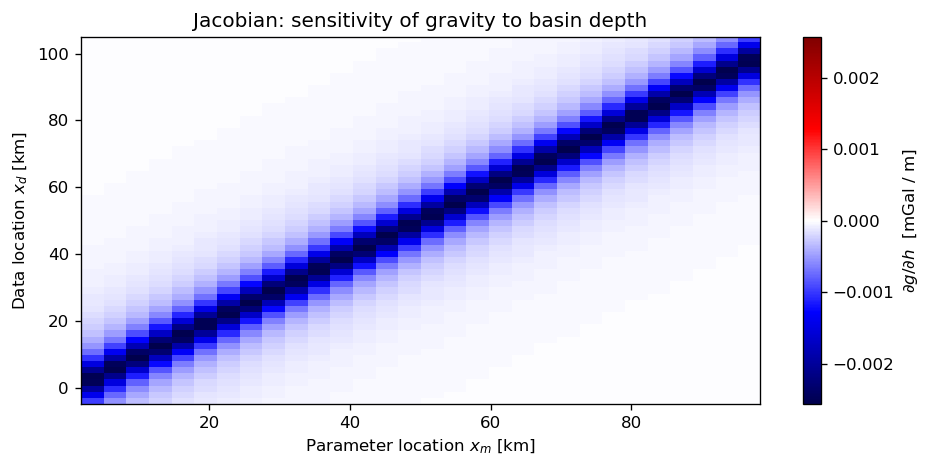

In [12]:
# Start with a simple constant-depth model (30 prism columns @ 5 km)
depths0 = np.full(30, 5_000.0)   # meters

# Finite-difference Jacobian (units ≈ mGal per meter of depth change)
jacobian = make_jacobian(depths0, basin_boundaries, density, x, delta=10.0)

# Use prism centers for the parameter x-locations
bnds = prism_boundaries(depths0, basin_boundaries)
x_model = 0.5 * (bnds[:-1] + bnds[1:])  # prism centers (m)

# Plot with physical coordinates on both axes
v = np.nanmax(np.abs(jacobian))  # symmetric color scale around 0
plt.figure(figsize=(8, 4))
plt.imshow(
    jacobian,
    origin="lower",
    aspect="auto",
    extent=[x_model.min()/1e3, x_model.max()/1e3, x.min()/1e3, x.max()/1e3],
    vmin=-v, vmax=v, cmap="seismic",
)
cbar = plt.colorbar()
cbar.set_label(r"$\partial g / \partial h$  [mGal / m]")

plt.xlabel("Parameter location $x_m$ [km]")
plt.ylabel("Data location $x_d$ [km]")
plt.title("Jacobian: sensitivity of gravity to basin depth")
plt.tight_layout()
plt.show()

In the figure above, we visualize the Jacobian matrix for our constructed basin model. 

- **What it is:** sensitivity matrix $J[i,j]\approx \partial g(x_d^i)/\partial h(x_m^j)$ in **mGal/m**
  (how much datum $i$ changes if prism $j$ is deepened by 1 m).

- **Axes:**
  - **x-axis (parameter location $x_m$)** = position of prism column along the profile
    *(this is the prism’s location, **not** its depth value)*.
  - **y-axis (data location $x_d$)** = gravity station position.

- **Diagonal ridge:** stations are most sensitive to the prism **directly beneath** them; sensitivity decreases away from the diagonal.

- **Sign (color):** with a **negative density contrast** (light basin), deepening makes gravity **more negative** → blue; reverse the contrast and the colors flip.

- **Blur width:** gravity has a broad footprint, so each station “sees” a **region** of prisms, not a single one.

> The plot shows **sensitivity to the model parameter** <u>**depth**</u>, not the depths themselves.



## Define the inverse problem (Gauss–Newton)

**Goal:** find basin depths that make the **predicted** gravity match the **measured** gravity.

**Objective (what we minimize):**
$
\phi(m) \;=\; \|\,d - F(m)\,\|_2^2
$
  
This is the **L2 data misfit** (sum of squared residuals).  

**What happens each loop (iteration):**
1. Start from a first **guess** of the depths.
2. **Predict** gravity from that guess (forward model).
3. Build the **Jacobian** (how each datum reacts to each depth change).
4. **Solve** a small linear system to get a **depth update** that should reduce the error.
5. **Update** the depths. If the error didn’t go down, take a **smaller step**.
6. Stop when the change is tiny or the error stops improving.

*In short: predict → measure sensitivities → take a better step → repeat.*


In [13]:
# Define Inversion Algorithm
def basin2d_inversion(x, data, basin_boundaries, density, initial, max_iterations=10):
    """
    Solve the inverse problem using the Gauss-Newton method.
    
    Parameters
    ----------
    x : array
        Observation positions.
    data : array
        Observed gravity data.
    basin_boundaries : tuple
        Start and end x-coordinates of the basin.
    density : float
        Density contrast (kg/m^3).
    initial : array
        Initial guess of model parameters (depths).
    max_iterations : int, optional
        Maximum number of iterations. Default = 10.
    
    Returns
    -------
    parameters : array
        Estimated model parameters (depths).
    goal_function : list
        Sum of squared residuals at each iteration.
    """
    # Start with initial guess
    parameters = initial.astype(np.float64).copy()
    
    # Compute first prediction and misfit
    predicted = forward_model(parameters, basin_boundaries, density, x)
    residuals = data - predicted
    goal_function = [np.linalg.norm(residuals) ** 2] # L2 misfit

    # Iterative Gauss-Newton updates
    for _ in range(max_iterations):
        # Sensitivities
        jacobian = make_jacobian(parameters, basin_boundaries, density, x)

        # Approximate Hessian and gradient
        hessian = jacobian.T @ jacobian
        gradient = jacobian.T @ residuals

        # Parameter update
        deltap = np.linalg.solve(hessian, gradient) 
        new_parameters = parameters + deltap

        # New prediction and misfit
        predicted = forward_model(new_parameters, basin_boundaries, density, x)
        residuals = data - predicted
        current_goal = np.linalg.norm(residuals) ** 2

        # Stop if misfit increases
        if current_goal > goal_function[-1]:
            break

        # Accept update
        parameters = new_parameters
        goal_function.append(current_goal)

    return parameters, goal_function


Now we can use this function to invert our synthetic data.

In [14]:
# Run the inversion starting from a flat initial guess (depth = 1000 m everywhere)
estimated, goal_function = basin2d_inversion(
    x,                 # X locations of the data (m)
    data,              # Data values (mGal)
    basin_boundaries,  # Start and end x-coordinates of the basin (m)
    density,           # Density contrast (kg/m^3)
    initial=np.full(30, 1000),  # 30 prism columns, each starting at 1000 m depth
)

# Compute the gravity response of the estimated basin model
predicted = forward_model(
    estimated,            # inverted basin depths
    basin_boundaries,     # x-extent of the basin
    density,              # Density contrast (kg/m^3)
    x                     # observation positions (m)
)


## Plot Observed vs Predicted data

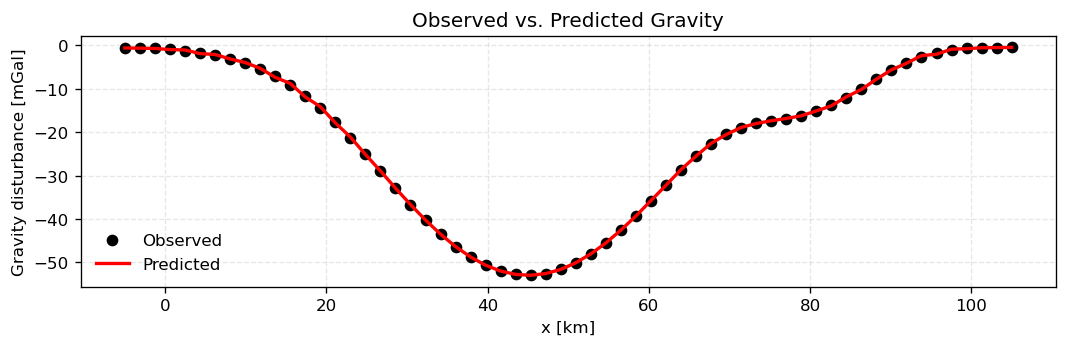

In [16]:
# Plot observed vs predicted gravity response
plt.figure(figsize=(9, 3))

# Observed data (black dots)
plt.plot(x / 1e3, data, "ok", label="Observed")

# Predicted data from inversion (red line)
plt.plot(x / 1e3, predicted, "-r", linewidth=2, label="Predicted")

# Labels, legend, and nicer layout
plt.xlabel("x [km]")
plt.ylabel("Gravity disturbance [mGal]")
plt.title("Observed vs. Predicted Gravity")
plt.legend(frameon=False)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


## Plot Convergence Curve

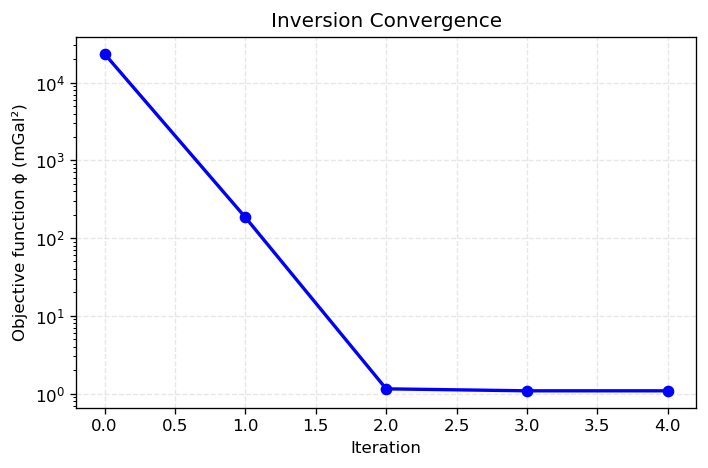

In [17]:
# Plot the objective (goal) function at each iteration
plt.figure(figsize=(6, 4))

plt.plot(goal_function, "o-", color="blue", linewidth=2, markersize=6)

# Log scale to highlight convergence
plt.yscale("log")

# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Objective function ϕ (mGal²)")
plt.title("Inversion Convergence")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


## Plot True Model vs Inverted Model

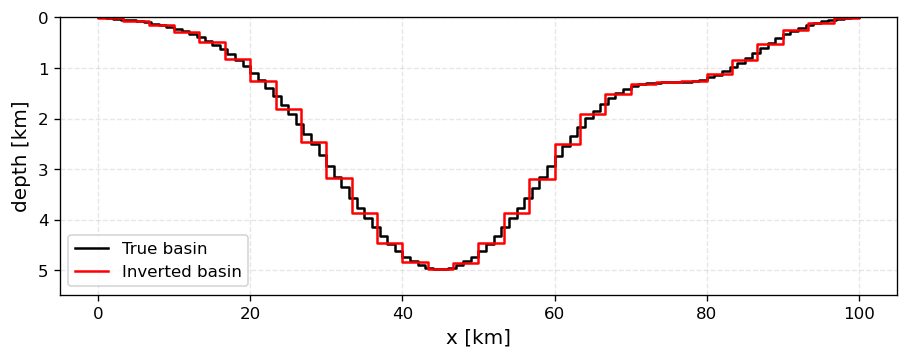

In [18]:
# Plot true vs estimated basin boundary
ax = plot_prisms(depths, basin_boundaries, label="True basin")
plot_prisms(estimated, basin_boundaries, ax=ax, edgecolor="red", label="Inverted basin")

ax.legend()
plt.show()

Perfect! It seems that our inversion works well under these conditions (departing from our **initial model** and with **no noise in the data**).. 

**Now let's break the inversion!**

## Add noise

Add pseudo-random noise to the data using `np.random.normal` function and investigate the effect this has on the inversion results.
  
A typical gravity survey has accuracy in between 0.5-1 mGal. 

In [19]:
# Generate Gaussian noise (mean=0, std=1 mGal)
# size=data.size ensures we have one noise value per observation
noise = np.random.normal(loc=0, scale=1, size=data.size)

# Add noise to the observed data
noisy_data = data + noise

In [20]:
# Reinvert with noisy data

# Use the same initial guess (flat basin at 1 km depth)
estimated, goal_function = basin2d_inversion(
    x, noisy_data, basin_boundaries, density, initial=np.full(30, 1000),
)

# Forward model prediction from the new estimated depths
predicted = forward_model(estimated, basin_boundaries, density, x)

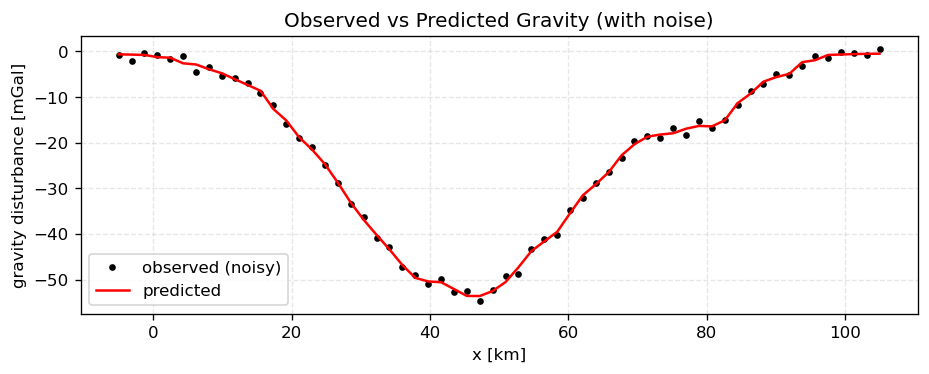

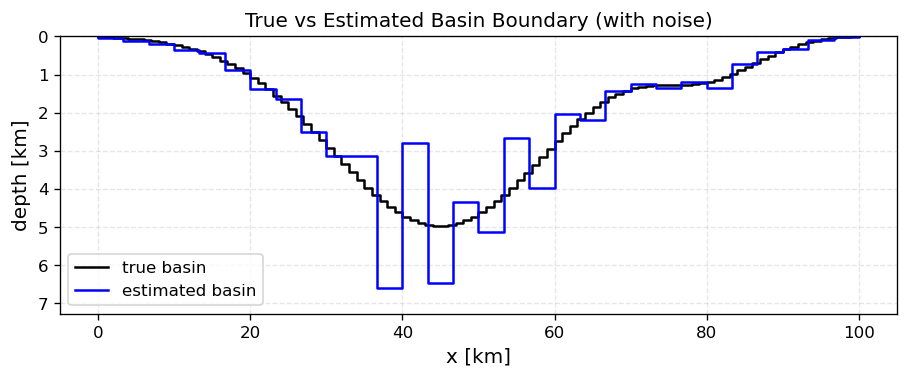

In [21]:
# Plot gravity data: noisy vs predicted
plt.figure(figsize=(9, 3))
plt.plot(x / 1e3, noisy_data, ".k", label="observed (noisy)")   # noisy data
plt.plot(x / 1e3, predicted, "-r", label="predicted")           # prediction from inversion
plt.legend()
plt.xlabel("x [km]")
plt.ylabel("gravity disturbance [mGal]")
plt.title("Observed vs Predicted Gravity (with noise)")
plt.grid(alpha=0.3, linestyle="--")
plt.show()

# --- Plot basin geometry: true vs estimated ---
ax = plot_prisms(depths, basin_boundaries, edgecolor="black", label="true basin")
plot_prisms(estimated, basin_boundaries, edgecolor="blue", ax=ax, label="estimated basin")
ax.legend()
ax.set_title("True vs Estimated Basin Boundary (with noise)")
plt.show()


Above, we demonstrated how adding some noise to the data (which is consistent with real-world conditions) can destabilize the inversion results.

## Multiple Inversions with Noise

**Real data** always contain **random noise**. To see how <u>**stable**</u> our inversion is, we can:

1. Add different random noise realizations to the same data.
2. Run the inversion each time.
3. Compare the estimated basin shapes.

If the solutions stay close together, the inversion is robust.
If they vary a lot, the problem is sensitive to noise.

In [22]:
# Run several inversions with different random noise realizations
estimates = []
for i in range(5):
    # Add Gaussian noise (mean=0, std=1 mGal)
    noise = np.random.normal(loc=0, scale=1, size=data.size)
    noisy_data = data + noise
    
    # Invert noisy data
    estimated, goal_function = basin2d_inversion(
        x, noisy_data, basin_boundaries, density, initial=np.full(30, 1000),
    )
    estimates.append(estimated)

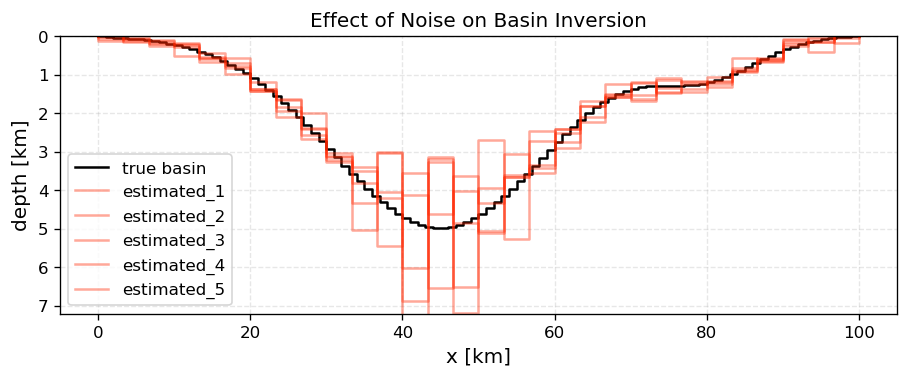

In [23]:
# Plot all estimated basins against the true one
ax = plot_prisms(depths, basin_boundaries, edgecolor="black", label="true basin")
for i, est in enumerate(estimates):
    plot_prisms(est, basin_boundaries, edgecolor="#ff260066", ax=ax, label=f"estimated_{i+1}")
ax.set_title("Effect of Noise on Basin Inversion")
plt.show()

The fact that **small changes in the data lead to large changes in the model** is the defining characteristic of an **unstable problem**.

## **Question time!** 
  

**Why does the inversion struggle to recover the deeper portions of the model in particular?** 

Hint: It's related to the physics of the forward modelling and the Jacobian matrix.

## Regularization to the rescue!! 
### Smoothness in X

Our inversion can get **wiggly** and unstable, especially at greater depths.  

To tame this, we add a **first-order Tikhonov regularization**, a smoothness penalty **along x**. 

**Idea:** penalize **differences between neighbouring depths** so the basin floor changes gradually. This is our regularization constraint.

We do this with a **finite-difference matrix** $R$ (1D in x) and minimize
$
\phi(m) \;=\; \|d - F(m)\|^2 \;+\; \beta\,\|R\,m\|^2,
$
where **β** controls how strong the smoothing is (bigger β → smoother model).

Next: build the finite-difference matrix $R$.


In [24]:
def finite_difference_matrix(nparams):
    """
    Create the finite difference matrix for regularization.
    Each row gives (next - current) for the model parameters.
    Size is based on the number of depth parameters.
    """
    nparams = nparams  # number of model parameters
    fdmatrix = np.zeros((nparams - 1, nparams))
    for i in range(nparams - 1):
        fdmatrix[i, i] = -1
        fdmatrix[i, i + 1] = 1
    return fdmatrix


**In other words:** this matrix just takes the difference between neighbors, so the inversion prefers models that don’t change too abruptly.

In [25]:
nparams = len(depths)  # number of depth parameters
R = finite_difference_matrix(nparams)

print(R, '\n')
print("Number of depth parameters:", len(R) + 1)

[[-1.  1.  0. ...  0.  0.  0.]
 [ 0. -1.  1. ...  0.  0.  0.]
 [ 0.  0. -1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ... -1.  1.  0.]
 [ 0.  0.  0. ...  0. -1.  1.]] 

Number of depth parameters: 100


Now we can use this to make a new inversion function with smoothness, minimizing:

$$
\phi(m) \;=\; \|d - F(m)\|^2 \;+\; \beta\,\|R\,m\|^2
$$

In [26]:
def basin2d_smooth_inversion(x, data, basin_boundaries, density, initial, smoothness, max_iterations=10):
    """
    Solve the regularized inverse problem using the Gauss-Newton method.
    """
    parameters = initial.astype(np.float64).copy() 
    predicted = forward_model(parameters, basin_boundaries, density, x)
    residuals = data - predicted
    goal_function = [np.linalg.norm(residuals)**2]
    fdmatrix = finite_difference_matrix(parameters.size)
    for i in range(max_iterations):       
        jacobian = make_jacobian(parameters, basin_boundaries, density, x)
        hessian = jacobian.T @ jacobian + smoothness * fdmatrix.T @ fdmatrix
        gradient = jacobian.T @ residuals - smoothness * fdmatrix.T @ fdmatrix @ parameters
        deltap = np.linalg.solve(hessian, gradient)
        new_parameters = parameters + deltap
        predicted = forward_model(new_parameters, basin_boundaries, density, x)
        residuals = data - predicted
        current_goal = np.linalg.norm(residuals)**2
        if current_goal > goal_function[-1]:
            break
        parameters = new_parameters
        goal_function.append(current_goal)
    return parameters, goal_function

Now we check if it works on our noisy data.

In [27]:
estimates = []
for i in range(5):
    noise = np.random.normal(loc=0, scale=1, size=data.size)
    noisy_data = data + noise
    estimated, goal_function = basin2d_smooth_inversion(
        x, noisy_data, basin_boundaries, density, initial=np.full(30, 1000), smoothness=1e-5
    )
    estimates.append(estimated)

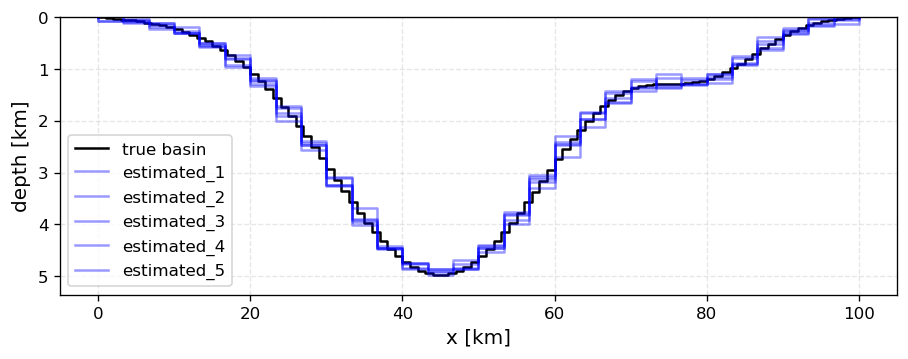

In [ ]:
# Plotting the true and estimated basin depths via inversion
ax = plot_prisms(depths, basin_boundaries, edgecolor="black", label="true basin")
for i, estimated in enumerate(estimates):
    plot_prisms(estimated, basin_boundaries, edgecolor="#0000ff66", ax=ax, label=f"estimated_{i+1}")

## **Question time!**

Given our objective function:

$
\phi(m) \;=\; \|d - F(m)\|^2 \;+\; \beta\,\|R\,m\|^2
$
  
**What happens when the regularization paramater **$\beta$** is extremely high?** Try to predict what the answer would be and then execute the code to check your reasoning.

Hint: what is the smoothest possible model?